**kMeans Clustering**

In dieser Aufgabe experimentieren wir mit dem kMeans Clusteringalgorithmus. Dazu erzeugen wir und erst einige künstliche Daten, wofür folgende Methoden verwendet werden können:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# create example data - method 1
def createData():
    
    # training
    np.random.seed(42) 
    # ...center
    mu = [0, 0]
    sigma = [[1, 0], [0, 1]]
    trainX = np.random.multivariate_normal(mu, sigma, 100)
    trainY = np.ones([trainX.shape[0], 1])
    # ...left|bottom|right
    mu = [-5, 0]
    sigma = [[1, 0], [0, 3]]
    trainX = np.block([[trainX], [np.random.multivariate_normal(mu, sigma, 50)]])
    trainY = np.block([[trainY], [-np.ones([50, 1])]])
    mu = [5, 0]
    sigma = [[1, 0], [0, 3]]
    trainX = np.block([[trainX], [np.random.multivariate_normal(mu, sigma, 50)]])
    trainY = np.block([[trainY], [-np.ones([50, 1])]])
    mu = [0, -4]
    sigma = [[5, 0], [0, 1]]
    trainX = np.block([[trainX], [np.random.multivariate_normal(mu, sigma, 50)]])
    trainY = np.block([[trainY], [-np.ones([50, 1])]])
    
    # testing
    # ...generate test points on grid
    steps = 0.1
    x = np.arange(-8, 8, steps)
    X1, X2 = np.meshgrid(x, x)
    testX = np.block( [ np.reshape(X1, [X1.shape[0]*X1.shape[1], 1] ), 
                        np.reshape(X2, [X1.shape[0]*X1.shape[1], 1] ) ])
    
    return (trainX, trainY, testX)


# create example data - method 2
def createData2():
    
    np.random.seed(42) 
    numSamples = 50
    # ...cluster 1
    mu = [-4.5, 2]
    sigma = [[1, 0], [0, 4]]
    trainX = np.random.multivariate_normal(mu, sigma, numSamples)
    trainY = 1*np.ones([numSamples, 1])
    # ...cluster 2
    mu = [0, 0]
    sigma = [[1, 0], [0, 2]]
    trainX = np.block([[trainX], [np.random.multivariate_normal(mu, sigma, numSamples)]])
    trainY = np.block([[trainY], [2*np.ones([numSamples, 1])]])
    #...cluster 3
    mu = [5, -4]
    sigma = [[3, 0], [0, 1]]
    trainX = np.block([[trainX], [np.random.multivariate_normal(mu, sigma, numSamples)]])
    trainY = np.block([[trainY], [3*np.ones([numSamples, 1])]])
    # ...cluster 4
    mu = [6, 6]
    sigma = [[3, 1], [1, 3]]
    trainX = np.block([[trainX], [np.random.multivariate_normal(mu, sigma, numSamples)]])
    trainY = np.block([[trainY], [4*np.ones([numSamples, 1])]])
    
    return  (trainX, trainY)



* Erzeugen Sie zunächst die beiden Datensets. Verwenden Sie dann eine geeignete Visualisierungstechnik aus der Vorlesung, um sich die (zweidimensionalen) Daten anzusehen.

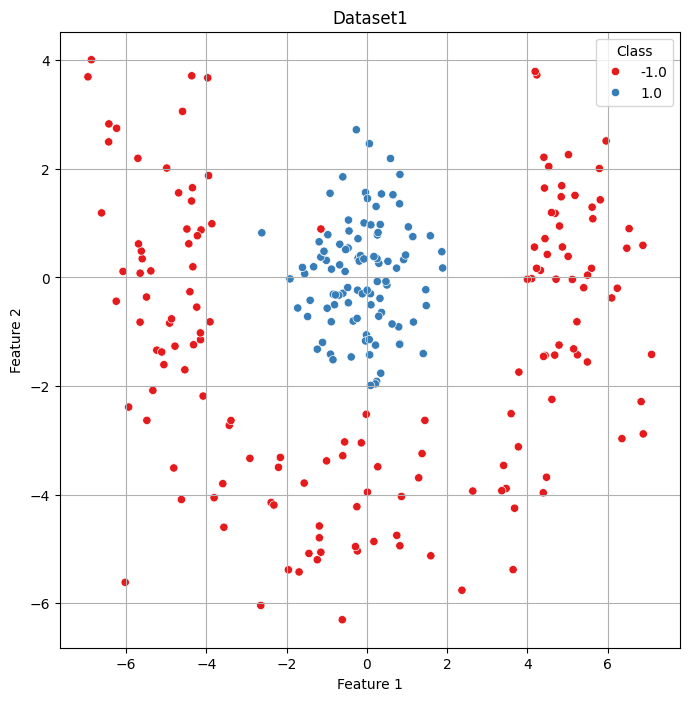

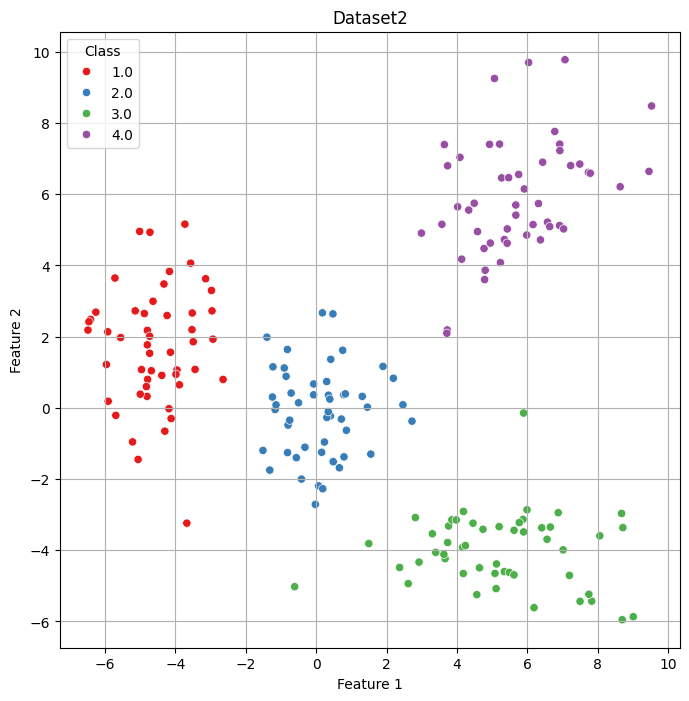

In [27]:
# TODO
# create training and test data
trainX, trainY, testX = createData()

# print(trainX, trainY, testX)

plt.figure(figsize=(8, 8))
plt.grid()
sns.scatterplot(x=trainX[:, 0], y=trainX[:, 1], hue=trainY[:, 0], palette='Set1')
plt.title('Dataset1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(title='Class')
plt.show()

# Just a Grid of Points
# plt.figure(figsize=(8, 8))
# plt.grid()
# sns.scatterplot(x=testX[:, 0], y=testX[:, 1])
# plt.title('Dataset1 Test Points')
# plt.xlabel('Feature 1')
# plt.ylabel('Feature 2')
# plt.show()

trainX2, trainY2 = createData2()

# print(trainX, trainY)

plt.figure(figsize=(8, 8))
plt.grid()
sns.scatterplot(x=trainX2[:, 0], y=trainX2[:, 1], hue=trainY2[:, 0], palette='Set1')
plt.title('Dataset2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(title='Class')
plt.show()

* Verwenden Sie die kMeans Implementierung der scikit-learn Library, um die mit createData (siehe oben) erzeugten Daten in Cluster einzuteilen. Dabei ist natürlich zu beachten, dass nur die Features, nicht aber die Labels verwendet werden. Überlegen Sie dann, wie eine geeignete Parametrierung des kMeans aussehen kann, experimentieren Sie mit geeigneten Settings.
* Visualisieren Sie die erhaltenen Cluster, indem Sie die Punkte nach Clusterzugehörigkeit gefärbt plotten!

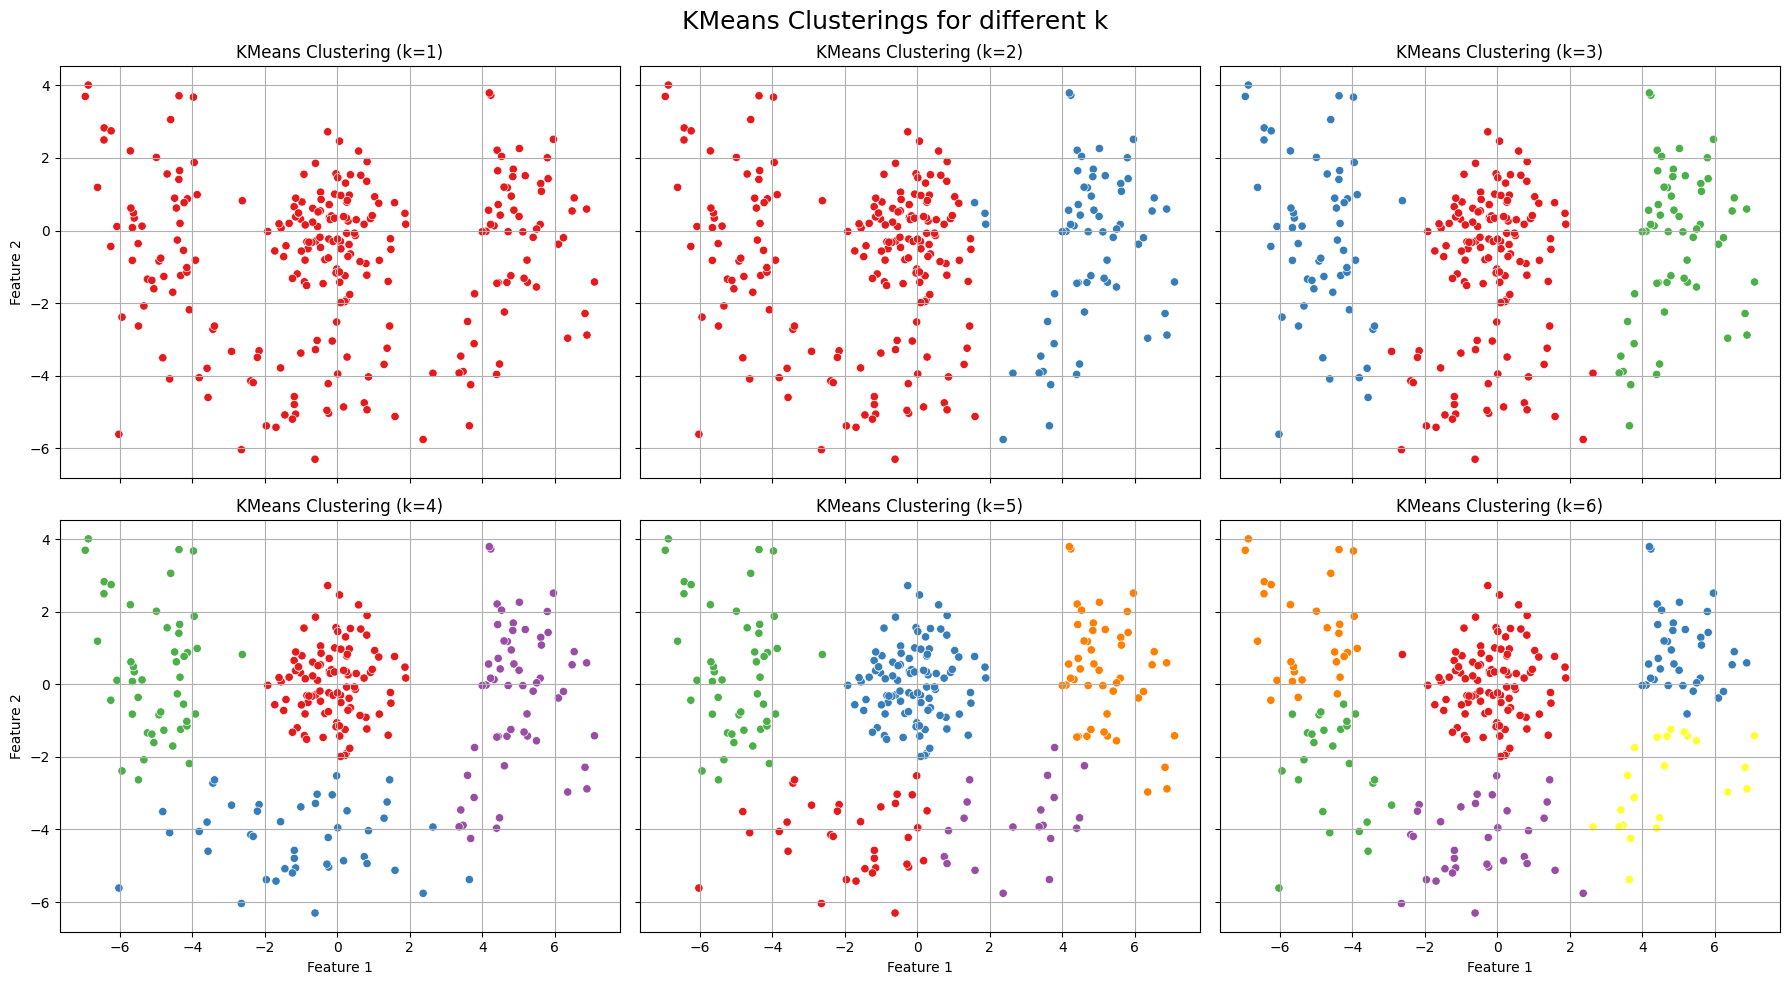

In [46]:
# TODO
# kMeans + visualize results for varying k's

from sklearn.cluster import KMeans

def visulize_KMeans(X):
    k_values = range(1, 7)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
    axes = axes.ravel()

    for ax, k in zip(axes, k_values):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)

        sns.scatterplot(
            x=X[:, 0],
            y=X[:, 1],
            hue=kmeans.labels_,
            palette='Set1',
            ax=ax,
            legend=False
        )
        ax.grid()
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')
        ax.set_title(f'KMeans Clustering (k={k})')

    fig.suptitle('KMeans Clusterings for different k', fontsize=18)
    plt.tight_layout()
    plt.show()

visulize_KMeans(trainX)

* Evaluieren Sie dann die Resultate, indem Sie z.B. die Purity (unter der Nutzung der wahren Labels in trainY) oder den Davies-Boulding oder Silhouette Score berechnen. Experimentieren Sie mit verschiedenen k und diskutieren Sie die Ergebnisse.

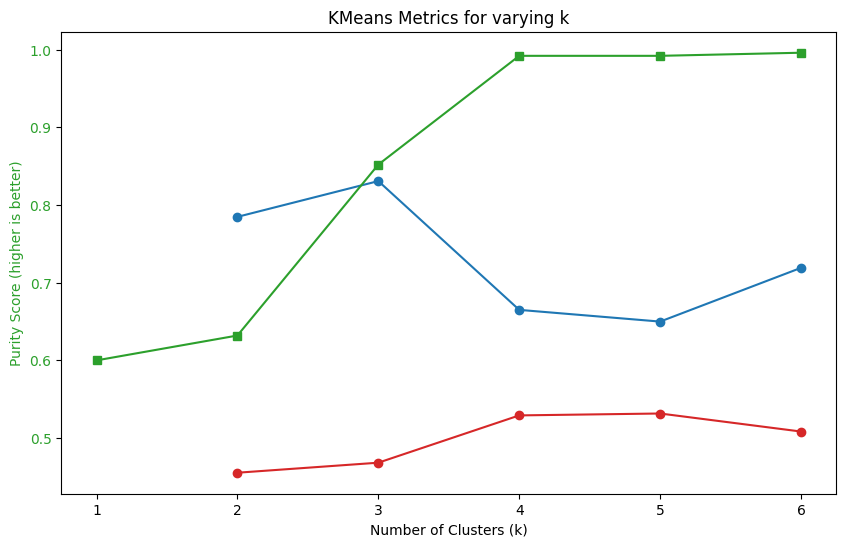

In [52]:
# TODO

# Compute metrics for varying k's and visualize the results
from sklearn.metrics import davies_bouldin_score, silhouette_score

def purity_score(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    if y_true.shape[0] != y_pred.shape[0]:
        raise ValueError('trainY and predicted labels must have the same length.')

    correct = 0
    for cluster_id in np.unique(y_pred):
        cluster_true_labels = y_true[y_pred == cluster_id]
        _, counts = np.unique(cluster_true_labels, return_counts=True)
        correct += counts.max()

    return correct / len(y_true)

def compute_metrics(X, y_true, k_values):
    db_index = []
    silhouette = []
    purity = []

    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)

        if k > 1:  # Both metrics are only defined for k > 1
            db_index.append(davies_bouldin_score(X, kmeans.labels_))
            silhouette.append(silhouette_score(X, kmeans.labels_))
        else:
            db_index.append(np.nan)
            silhouette.append(np.nan)

        purity.append(purity_score(y_true, kmeans.labels_))

    return db_index, silhouette, purity

def visulize_metrics(k_values, db_index, silhouette, purity):
    fig, ax = plt.subplots(figsize=(10, 6))

    color = 'tab:blue'
    ax.set_xlabel('Number of Clusters (k)')
    ax.set_ylabel('Davies-Bouldin Index (lower is better)', color=color)
    ax.plot(k_values, db_index, marker='o', color=color)
    ax.tick_params(axis='y', labelcolor=color)

    color = 'tab:red'
    ax.set_ylabel('Silhouette Score (higher is better)', color=color)
    ax.plot(k_values, silhouette, marker='o', color=color)
    ax.tick_params(axis='y', labelcolor=color)

    color = 'tab:green'
    ax.set_ylabel('Purity Score (higher is better)', color=color)
    ax.plot(k_values, purity, marker='s', color=color)
    ax.tick_params(axis='y', labelcolor=color)

    plt.title('KMeans Metrics for varying k')
    plt.show()

k_values = range(1, 7)

# Evaluate Dataset 1 with trainY
db_index, silhouette, purity = compute_metrics(trainX, trainY, k_values)
visulize_metrics(k_values, db_index, silhouette, purity)

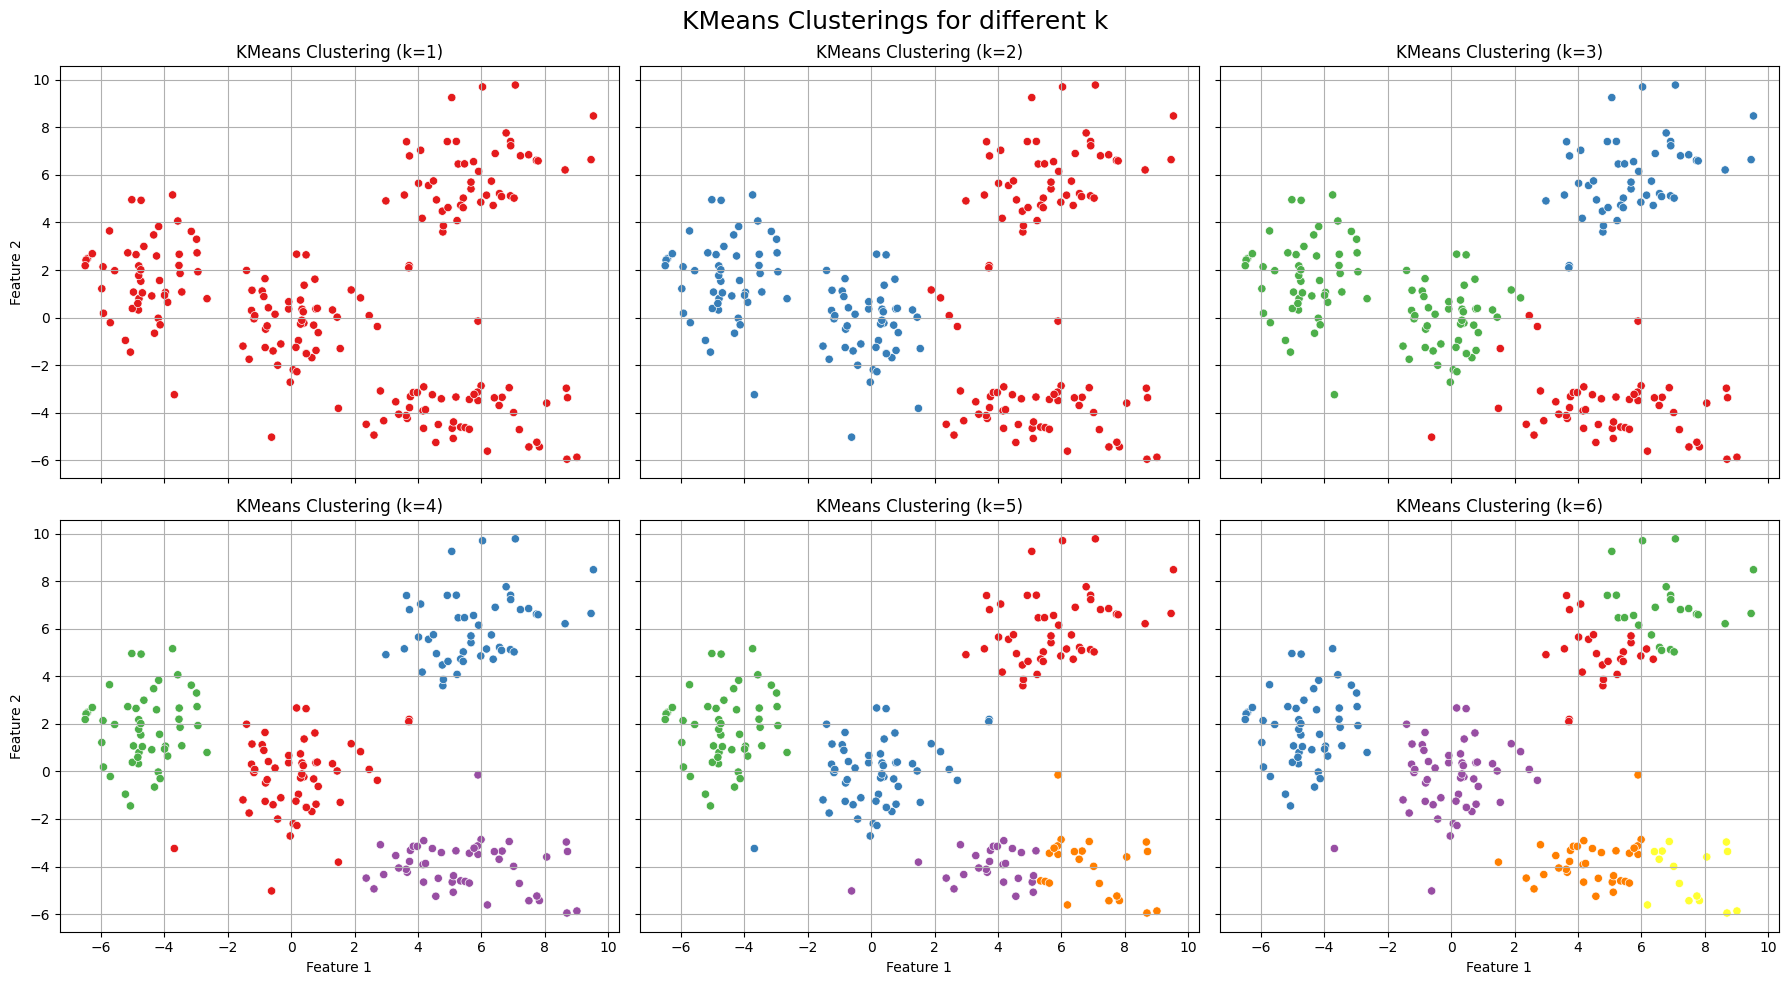

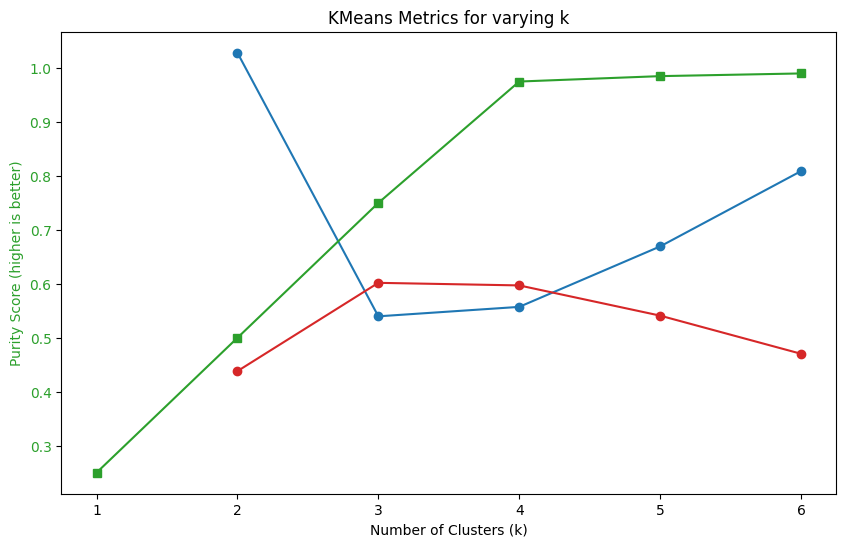

In [53]:
visulize_KMeans(trainX2)

k_values = range(1, 7)
db_index, silhouette, purity = compute_metrics(trainX2, trainY2, k_values)
visulize_metrics(k_values, db_index, silhouette, purity)